<a href="https://colab.research.google.com/github/adenikeadewumi/AWS-AI-ML-program/blob/main/Emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install timm
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets

In [31]:
class EmotionModel(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionModel, self).__init__()
        # Load pre-trained EfficientNet-B0
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True)

        # Remove the original classifier head
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()

        # Add our custom Portfolio-Grade Head
        self.attention = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_features),
            nn.Sigmoid() # This creates the "Attention Mask"
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3), # Prevents overfitting
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        # Apply self-attention
        attention_weight = self.attention(features)
        focused_features = features * attention_weight

        logits = self.classifier(focused_features)
        return logits

Loading in kaggle token

In [5]:
import os
import json

# Replace these with your actual Kaggle details
data = {
    "username": "adewumiadenike",
    "key": "KGAT_18125d188812ac85d0f901e2efba5103"
}

# Create the .kaggle directory
!mkdir -p ~/.kaggle

# Write the credentials to the kaggle.json file
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(data, f)

# Set the correct permissions (Kaggle requires 600)
!chmod 600 ~/.kaggle/kaggle.json

# Test the connection
!kaggle datasets list -s "emotion"

ref                                                        title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ananthu017/emotion-detection-fer                           Emotion Detection                                68327503  2020-12-11 06:06:37.220000          49195        353  0.875            
abdallahwagih/emotion-dataset                              Emotion Dataset                                    218317  2023-10-12 14:27:11.213000           8690        166  1                
danielshanbalico/dog-emotion                               Dog Emotion                                     162237964  2023-02-09 09:58:36.820000           7630         74  1                
parulpandey/emotion-dataset                       

In [6]:
# 1. Download the dataset
!kaggle datasets download -d shuvoalok/raf-db-dataset

# 2. Create a folder and unzip it
!mkdir -p dataset
!unzip -q raf-db-dataset.zip -d ./dataset

# 3. Clean up the zip file to save space
!rm raf-db-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
100% 37.7M/37.7M [00:03<00:00, 11.9MB/s]



In [10]:
import os

# Check the folder structure
base_path = './dataset/DATASET/train'
emotions = os.listdir(base_path)
print(f"Emotions found: {emotions}")

# Count images in each category to check for imbalance
for emotion in emotions:
    count = len(os.listdir(os.path.join(base_path, emotion)))
    print(f"{emotion}: {count} images")

Emotions found: ['1', '7', '6', '2', '5', '4', '3']
1: 1290 images
7: 2524 images
6: 705 images
2: 281 images
5: 1982 images
4: 4772 images
3: 717 images


Transform the dataset to what efficient net understands

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Standard size for EfficientNet
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # Small tilts mimic real head movement
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Robot-eye simulation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [24]:
from torch.utils.data import DataLoader, random_split

# 1. Load the separate folders
# Use train_transforms for training (augmentation) and test_transforms for validation/test
train_dataset = datasets.ImageFolder(root='/content/dataset/DATASET/train', transform=train_transforms)
full_test_folder = datasets.ImageFolder(root='/content/dataset/DATASET/test', transform=test_transforms)

# 2. Split the Test folder into 80% Validation and 20% Test
total_test_size = len(full_test_folder)
val_size = int(0.8 * total_test_size)
test_size = total_test_size - val_size

# random_split ensures we get a mix of all 7 emotions in both sets
val_data, test_data = random_split(full_test_folder, [val_size, test_size])

# 3. Create the Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print(f"--- Data Integrity Check ---")
print(f"Training:   {len(train_dataset)} images")
print(f"Validation: {len(val_data)} images ")
print(f"Testing:    {len(test_data)} images")

--- Data Integrity Check ---
Training:   12271 images
Validation: 2454 images 
Testing:    614 images


In [25]:
len(test_data)

614

Training Loop

In [18]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'


In [26]:
@torch.no_grad() # This tells PyTorch: "Don't calculate gradients, we are just testing"
def evaluate(model, val_loader):
    model.eval() # Set to evaluation mode (turns off Dropout)
    correct = 0
    total = 0

    # We'll use these to track which emotions are confused
    all_preds = []
    all_labels = []

    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Save for later analysis
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy

In [40]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    best_acc = 0.0

    for epoch in range(epochs):
        model.train() # Set to training mode
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            optimizer.step()
            # --- ONE STEP PER BATCH ---
            scheduler.step()

            running_loss += loss.item() * inputs.size(0)

        # --- End of Epoch Logic ---
        epoch_loss = running_loss / len(train_loader.dataset)
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # SAVE THE BEST MODEL
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_emotion_model.pth')
            print(f"New Best Model Saved! Acc: {best_acc:.2f}%")

# IMPORTANT: Reset the scheduler/optimizer before calling this
# optimizer = torch.optim.AdamW(...)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(...)

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, val_loader, classes):
    model.eval()
    y_pred = []
    y_true = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()

In [39]:
# 1. Create the Model Instance
model = EmotionModel(num_classes=7).to(device)

# 2. UNLOCK THE BRAIN (Put the code here!)
for param in model.backbone.parameters():
    param.requires_grad = True

# 3. Define the Optimizer (It now "sees" the unlocked parameters)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# 4. Define the Scheduler and Criterion
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)
# max_lr should be about 10x your starting lr (e.g., 1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=15
)

Run the pipeline

In [ ]:
# Start the training!
# Note: Since you're in Colab, 15 epochs should take about 20-30 mins on a T4 GPU.
train_history = train_model(
    model,
    train_loader,
    val_loader, # Using test_loader as our validation set
    criterion,
    optimizer,
    scheduler,
    epochs=15
)

In [44]:
from google.colab import files

# This will trigger a browser download for your model file
files.download('best_emotion_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏆 AVERAGE TEST ACCURACY: 84.69%


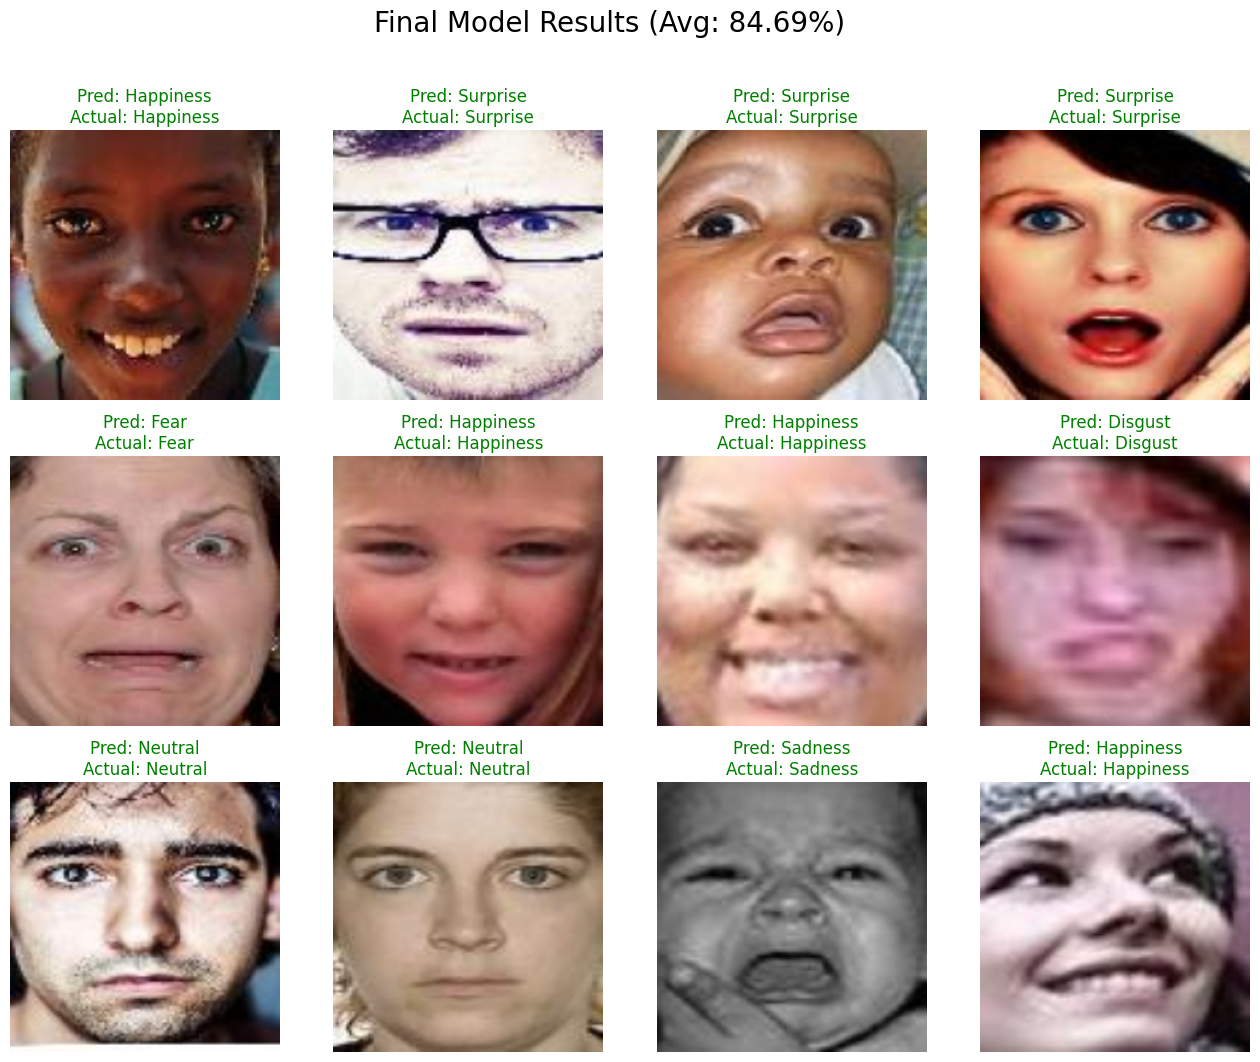

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def run_final_visual_test(model, loader, device):
    # Mapping Indices (0-6) back to RAF-DB Folder Words (1-7)
    emotion_words = {
        0: "Surprise", 1: "Fear", 2: "Disgust",
        3: "Happiness", 4: "Sadness", 5: "Anger", 6: "Neutral"
    }

    model.eval()
    all_preds, all_labels = [], []
    imgs_to_plot, preds_to_plot, labels_to_plot = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if len(imgs_to_plot) < 12:
                imgs_to_plot.extend(images.cpu())
                preds_to_plot.extend(preds.cpu().numpy())
                labels_to_plot.extend(labels.cpu().numpy())

    # Calculate Average
    final_acc = accuracy_score(all_labels, all_preds) * 100
    print(f"\n🏆 AVERAGE TEST ACCURACY: {final_acc:.2f}%")

    # Plot Grid
    plt.figure(figsize=(16, 12))
    for i in range(min(len(imgs_to_plot), 12)):
        # Inverse Transform for RGB display
        img = imgs_to_plot[i].numpy().transpose((1, 2, 0))
        img = (np.array([0.229, 0.224, 0.225]) * img) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)

        p_word, a_word = emotion_words[preds_to_plot[i]], emotion_words[labels_to_plot[i]]
        color = 'green' if p_word == a_word else 'red'
        plt.title(f"Pred: {p_word}\nActual: {a_word}", color=color)
        plt.axis('off')

    plt.suptitle(f"Final Model Results (Avg: {final_acc:.2f}%)", fontsize=20)
    plt.show()

# Execute final report
run_final_visual_test(model, test_loader, device)

In [2]:
image_path="/content/my_picture_-cropped.jpeg"
#Write code to test inference on the image



NameError: name 'model' is not defined